<a href="https://colab.research.google.com/github/mentor-pranaya/Cricket-Player-Performance-Prediction/blob/akshaya/Milestone1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/cricket_ml


deliveries.csv	matches.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [ ]:
deliveries_df = pd.read_csv('/content/drive/MyDrive/cricket_ml/deliveries.csv')
matches_df = pd.read_csv('/content/drive/MyDrive/cricket_ml/matches.csv')


In [ ]:
print("Deliveries:", deliveries_df.shape)
print("Matches:", matches_df.shape)

deliveries_df.head(), matches_df.head()


Deliveries: (260920, 17)
Matches: (1095, 20)


(   match_id  inning           batting_team                 bowling_team  over  \
 0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
 1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
 2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
 3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
 4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
 
    ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
 0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
 1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
 2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
 3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
 4     5  BB McCullum  P Kumar   SC Ganguly             0           0   
 
    total_runs extras_type  is_wicket player_dismissed dismissal_k

In [ ]:
print("Deliveries columns:")
print(deliveries_df.columns)

print("\nMatches columns:")
print(matches_df.columns)

deliveries_df.info()
matches_df.info()


Deliveries columns:
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

Matches columns:
Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4 

In [ ]:
deliveries_df.isnull().sum()


,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


In [ ]:
matches_df.isnull().sum()


,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


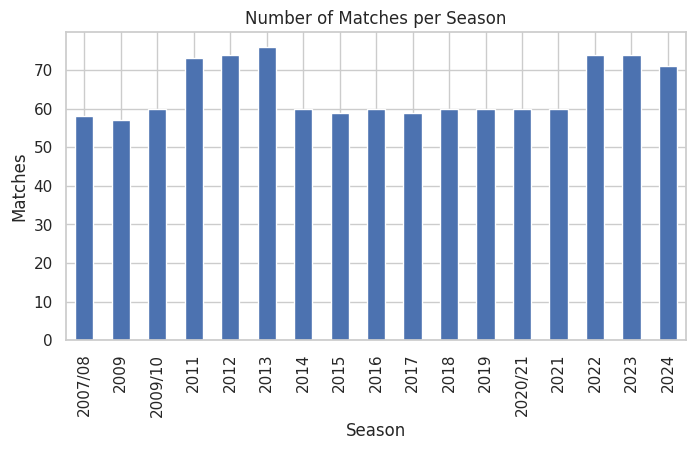

In [ ]:
plt.figure(figsize=(8,4))
matches_df['season'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Matches per Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.show()


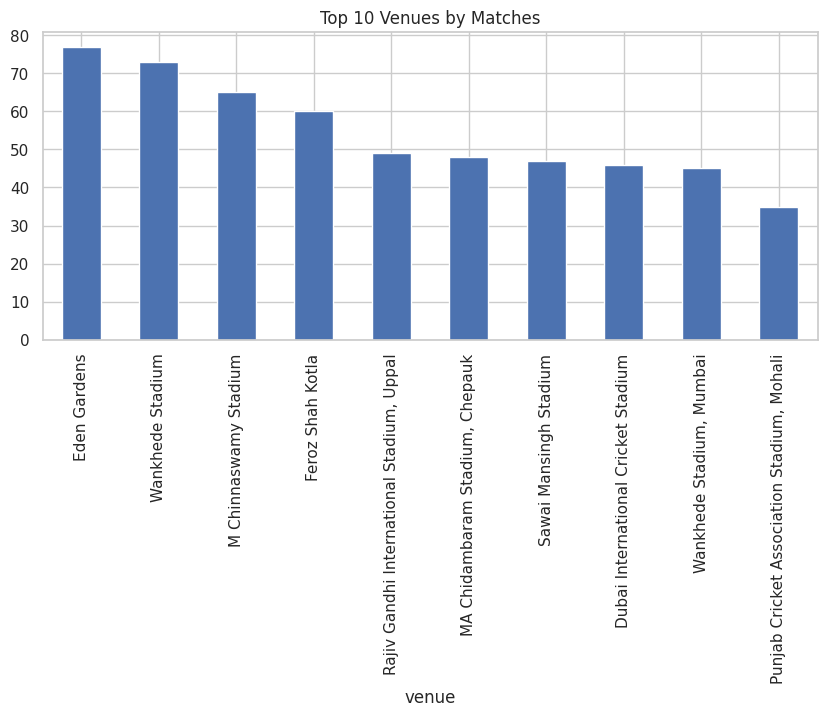

In [ ]:
plt.figure(figsize=(10,4))
matches_df['venue'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Venues by Matches")
plt.show()


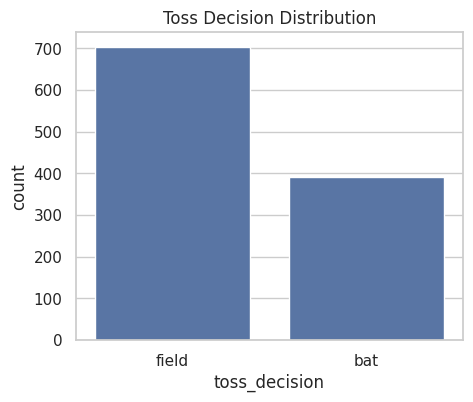

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='toss_decision', data=matches_df)
plt.title("Toss Decision Distribution")
plt.show()


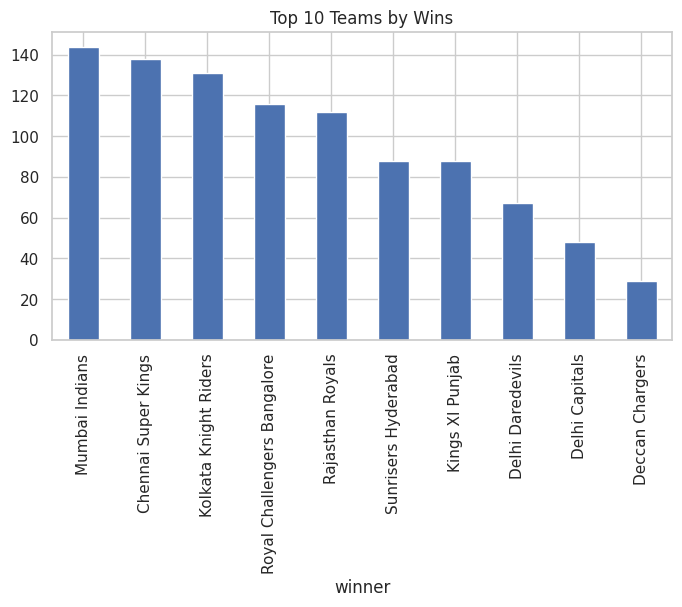

In [ ]:
plt.figure(figsize=(8,4))
matches_df['winner'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Teams by Wins")
plt.show()


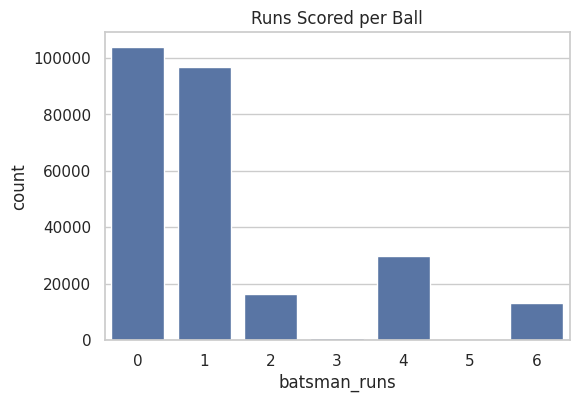

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='batsman_runs', data=deliveries_df)
plt.title("Runs Scored per Ball")
plt.show()


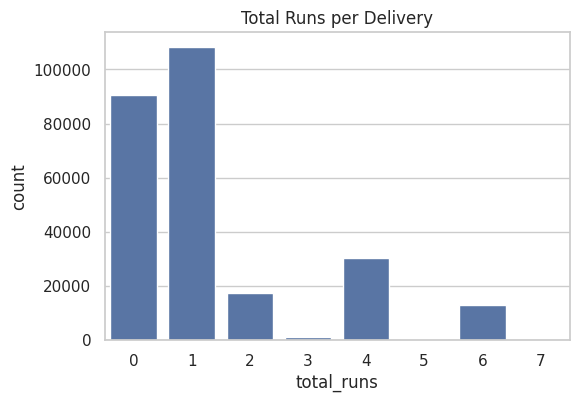

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='total_runs', data=deliveries_df)
plt.title("Total Runs per Delivery")
plt.show()


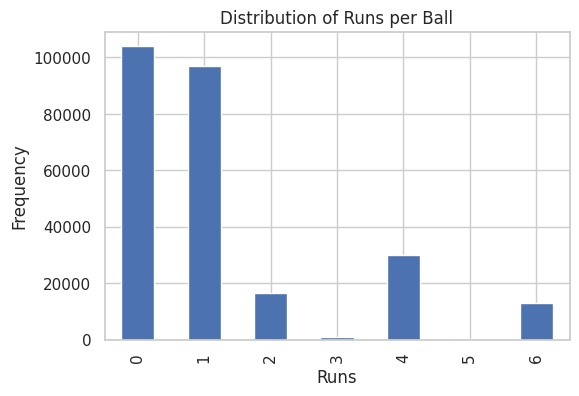

In [ ]:
boundary_counts = deliveries_df['batsman_runs'].value_counts().sort_index()

boundary_counts.plot(kind='bar', figsize=(6,4))
plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()


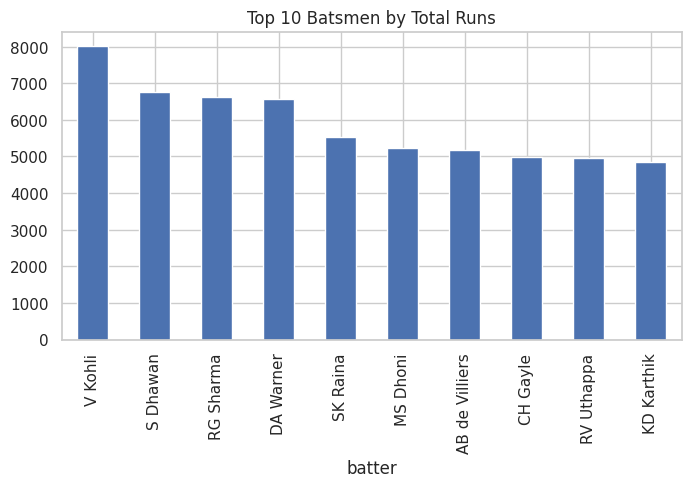

In [ ]:
top_batsmen = deliveries_df.groupby('batter')['batsman_runs'].sum() \
                           .sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
top_batsmen.plot(kind='bar')
plt.title("Top 10 Batsmen by Total Runs")
plt.show()


In [ ]:
batsman_stats = deliveries_df.groupby('batter').agg(
    runs=('batsman_runs','sum'),
    balls=('ball','count')
).reset_index()

batsman_stats.head()


,batter,runs,balls
0,A Ashish Reddy,280,196
1,A Badoni,634,505
2,A Chandila,4,7
3,A Chopra,53,75
4,A Choudhary,25,20


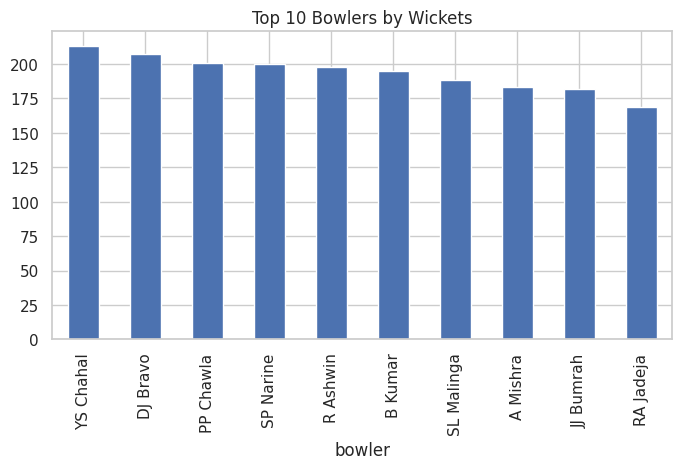

In [ ]:
wickets_df = deliveries_df[deliveries_df['dismissal_kind'].notnull()]
top_bowlers = wickets_df['bowler'].value_counts().head(10)

plt.figure(figsize=(8,4))
top_bowlers.plot(kind='bar')
plt.title("Top 10 Bowlers by Wickets")
plt.show()


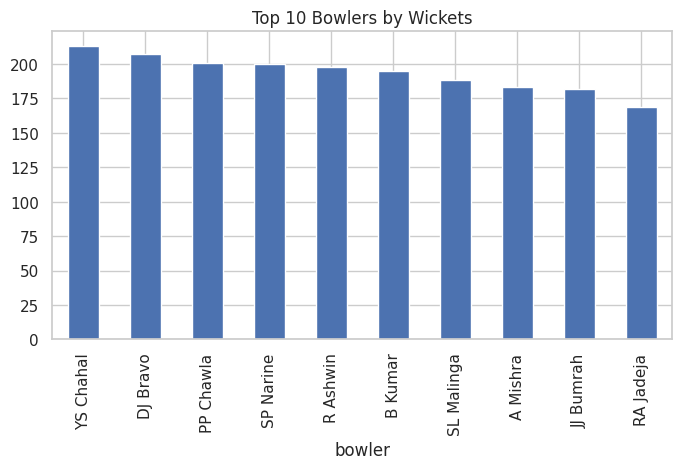

In [ ]:
wickets_df = deliveries_df[deliveries_df['dismissal_kind'].notnull()]
top_bowlers = wickets_df['bowler'].value_counts().head(10)

plt.figure(figsize=(8,4))
top_bowlers.plot(kind='bar')
plt.title("Top 10 Bowlers by Wickets")
plt.show()


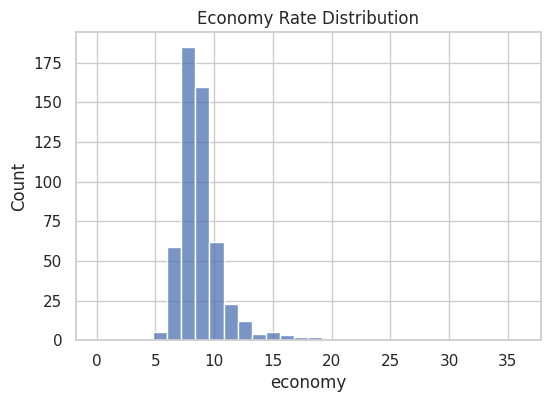

In [ ]:
bowler_stats = deliveries_df.groupby('bowler').agg(
    runs_conceded=('total_runs','sum'),
    balls=('ball','count')
)

bowler_stats['economy'] = (bowler_stats['runs_conceded'] / bowler_stats['balls']) * 6

plt.figure(figsize=(6,4))
sns.histplot(bowler_stats['economy'], bins=30)
plt.title("Economy Rate Distribution")
plt.show()


In [ ]:
merged_df = deliveries_df.merge(
    matches_df[['id','season','venue','team1','team2','winner']],
    left_on='match_id',
    right_on='id',
    how='left'
)

merged_df.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,is_wicket,player_dismissed,dismissal_kind,fielder,id,season,venue,team1,team2,winner
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,0,NaN,NaN,NaN,335982,2007/08,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,NaN,NaN,335982,2007/08,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,NaN,NaN,335982,2007/08,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,NaN,NaN,335982,2007/08,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,0,NaN,NaN,NaN,335982,2007/08,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders


In [ ]:
player_match_runs = merged_df.groupby(
    ['season','match_id','batter']
)['batsman_runs'].sum().reset_index()

player_match_runs.head()


,season,match_id,batter,batsman_runs
0,2007/08,335982,AA Noffke,9
1,2007/08,335982,B Akhil,0
2,2007/08,335982,BB McCullum,158
3,2007/08,335982,CL White,6
4,2007/08,335982,DJ Hussey,12
